##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
import os

os.makedirs("data", exist_ok=True)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3680
    })
    test: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3669
    })
})

Selected Images: 20
Cats: 10
Dogs: 10


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]


DINOv2 loaded successfully ✅

Embeddings shape: (20, 384)
PCA shape: (20, 5)

Predicted Clusters:
[1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1]

Best Clustering Accuracy: 1.00


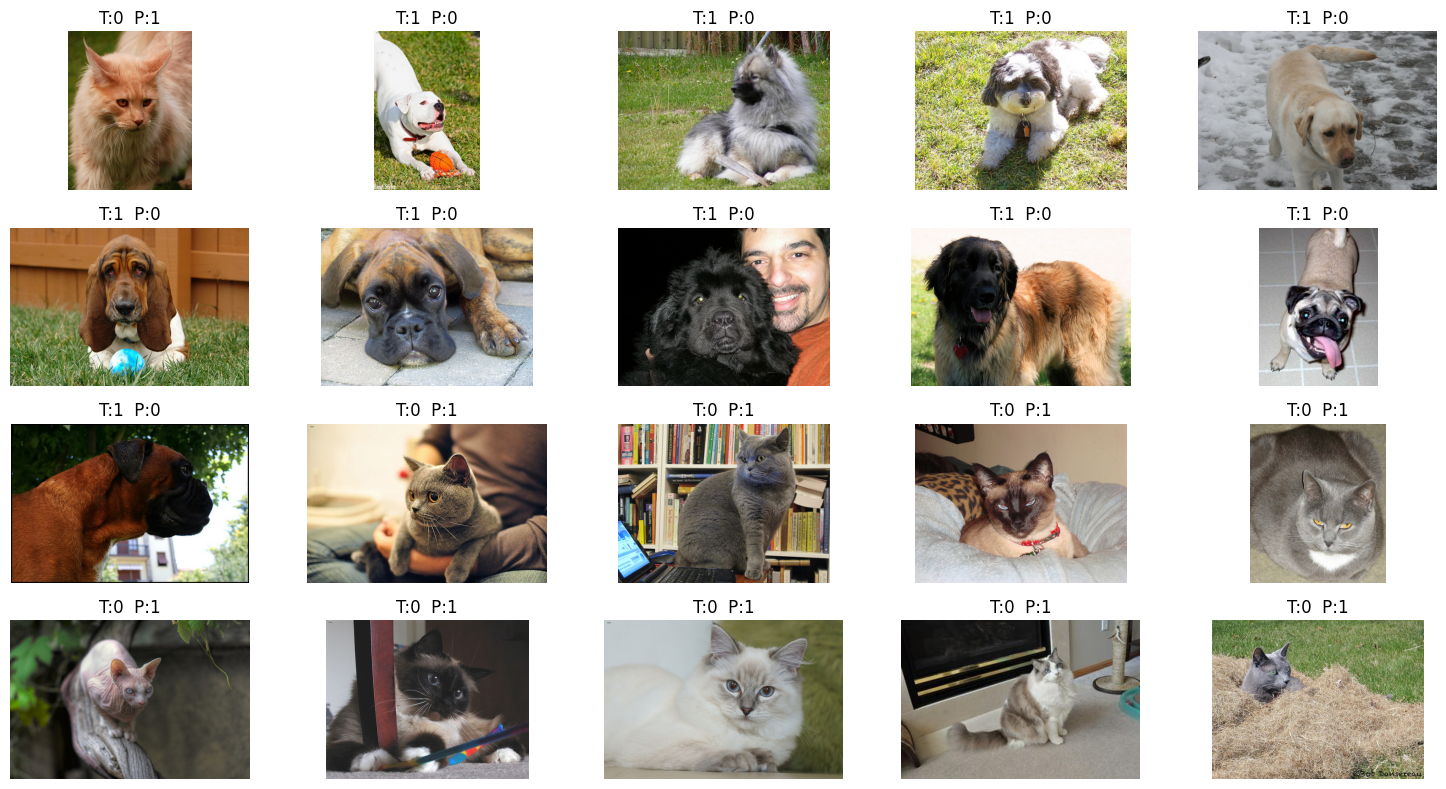

In [10]:
# Install packages
# =========================================================
# Exercise 1: Unsupervised Clustering with DINOv2
# Oxford-IIIT Pet Dataset
# =========================================================

# -------------------------------------------------
# Install required packages
# -------------------------------------------------

!pip install -q transformers datasets torch torchvision scikit-learn matplotlib pillow

# -------------------------------------------------
# Imports
# -------------------------------------------------

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from datasets import load_dataset

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from transformers import AutoImageProcessor, AutoModel

# -------------------------------------------------
# Step 1: Load Oxford-IIIT Pet Dataset
# -------------------------------------------------

dataset = load_dataset("timm/oxford-iiit-pet")

print(dataset)

# -------------------------------------------------
# Step 2: Select 20 images
# 10 cats + 10 dogs
# -------------------------------------------------

images = []
true_labels = []

cat_count = 0
dog_count = 0

for sample in dataset["train"]:

    image = sample["image"]

    # 0 = cat
    # 1 = dog

    label = sample["label_cat_dog"]

    # -------------------------------
    # Select cats
    # -------------------------------

    if label == 0 and cat_count < 10:

        images.append(image)

        true_labels.append(0)

        cat_count += 1

    # -------------------------------
    # Select dogs
    # -------------------------------

    elif label == 1 and dog_count < 10:

        images.append(image)

        true_labels.append(1)

        dog_count += 1

    # Stop after 20 images

    if cat_count == 10 and dog_count == 10:
        break

print(f"\nSelected Images: {len(images)}")
print(f"Cats: {cat_count}")
print(f"Dogs: {dog_count}")

# -------------------------------------------------
# Step 3: Load DINOv2 model
# -------------------------------------------------

model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModel.from_pretrained(model_name)

print("\nDINOv2 loaded successfully ✅")

# -------------------------------------------------
# Step 4: Extract CLS embeddings
# -------------------------------------------------

embeddings = []

for image in images:

    image = image.convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():

        outputs = model(**inputs)

    # CLS token embedding

    cls_embedding = outputs.last_hidden_state[:, 0, :]

    embeddings.append(
        cls_embedding.squeeze().numpy()
    )

embeddings = np.array(embeddings)

print("\nEmbeddings shape:", embeddings.shape)

# -------------------------------------------------
# Step 5: Normalize embeddings
# -------------------------------------------------

scaler = StandardScaler()

embeddings_scaled = scaler.fit_transform(embeddings)

# -------------------------------------------------
# Step 6: PCA dimensionality reduction
# -------------------------------------------------

pca = PCA(n_components=5)

embeddings_pca = pca.fit_transform(embeddings_scaled)

print("PCA shape:", embeddings_pca.shape)

# -------------------------------------------------
# Step 7: KMeans clustering
# -------------------------------------------------

kmeans = KMeans(
    n_clusters=2,
    random_state=0,
    n_init=100
)

predicted_clusters = kmeans.fit_predict(
    embeddings_pca
)

print("\nPredicted Clusters:")
print(predicted_clusters)

# -------------------------------------------------
# Step 8: Calculate clustering accuracy
# -------------------------------------------------

acc1 = accuracy_score(
    true_labels,
    predicted_clusters
)

acc2 = accuracy_score(
    true_labels,
    1 - predicted_clusters
)

best_accuracy = max(acc1, acc2)

print(f"\nBest Clustering Accuracy: {best_accuracy:.2f}")

# -------------------------------------------------
# Step 9: Display clustering results
# -------------------------------------------------

plt.figure(figsize=(15,8))

for i in range(20):

    plt.subplot(4,5,i+1)

    plt.imshow(images[i])

    plt.axis("off")

    plt.title(
        f"T:{true_labels[i]}  P:{predicted_clusters[i]}"
    )

plt.tight_layout()

plt.show()


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Image loaded successfully


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

DINOv2 model loaded

Predicted Class: pug, pug-dog

Top 5 Predictions:

pug, pug-dog              0.9290
Brabancon griffon         0.0587
feather boa, boa          0.0016
bath towel                0.0015
schipperke                0.0013


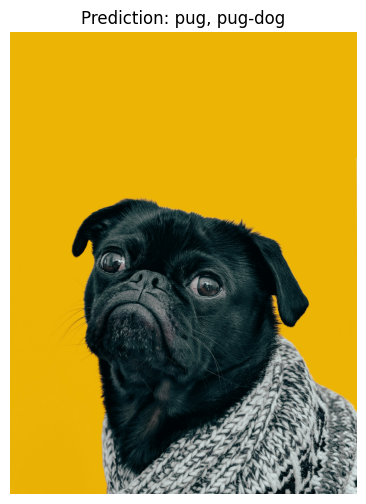

In [ ]:
# Provide your solution here
# Install required packages
!pip install -q transformers torch torchvision pillow requests matplotlib

import torch
import requests
import matplotlib.pyplot as plt

from PIL import Image
from io import BytesIO

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification
)

# Image URL
image_url = "https://images.unsplash.com/photo-1517849845537-4d257902454a"

# Download image correctly
response = requests.get(image_url)

image = Image.open(BytesIO(response.content)).convert("RGB")

print("Image loaded successfully")

# Load DINOv2 classification model
model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)

model = AutoModelForImageClassification.from_pretrained(model_id)

print("DINOv2 model loaded")

# Preprocess image
inputs = processor(
    images=image,
    return_tensors="pt"
)

# Run inference
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

# Prediction
predicted_class_idx = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_idx]

print(f"\nPredicted Class: {predicted_label}")

# Top 5 predictions
probabilities = torch.nn.functional.softmax(logits, dim=-1)

top5_prob, top5_catid = torch.topk(probabilities, 5)

print("\nTop 5 Predictions:\n")

for i in range(5):

    label = model.config.id2label[top5_catid[0][i].item()]

    prob = top5_prob[0][i].item()

    print(f"{label:<25} {prob:.4f}")

# Display image
plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(f"Prediction: {predicted_label}")

plt.axis("off")

plt.show()